<a href="https://colab.research.google.com/github/Kylekk29/ImageAIUpscaler/blob/main/ImageAIUpscaler.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#@title 1. ⚙️ Install Real-ESRGAN Engine & Setup Environment (with Auto-Cleanup)
#@markdown Click the "Play" button on the left to set up the environment.
#@markdown This will clear previous inputs and install all dependencies.

import os
import shutil
import site
import subprocess
import sys
from IPython.display import clear_output

print("="*80)
print("🚀 REAL-ESRGAN ENVIRONMENT SETUP".center(80))
print("="*80)

# ============================================================================
# STEP 1: CLEANUP OLD FILES AND FOLDERS
# ============================================================================
print("\n🧹 STEP 1: Cleaning up previous installations...")

# List of folders to clean
folders_to_clean = ['inputs', 'results', 'output', '/content/Real-ESRGAN']
for folder in folders_to_clean:
    if os.path.exists(folder):
        try:
            shutil.rmtree(folder)
            print(f"   ✅ Removed: {folder}")
        except Exception as e:
            print(f"   ⚠️ Could not remove {folder}: {e}")

# Also clean any old zip files
for file in os.listdir('/content/'):
    if file.startswith('Enhanced_') and file.endswith('.zip'):
        try:
            os.remove(os.path.join('/content/', file))
            print(f"   ✅ Removed old zip: {file}")
        except:
            pass

print("   ✅ Cleanup complete!")

# ============================================================================
# STEP 2: INSTALL DEPENDENCIES
# ============================================================================
print("\n📦 STEP 2: Installing required dependencies...")

# Essential packages that might need pre-installation
essential_packages = [
    'torch', 'torchvision', 'torchaudio',
    'opencv-python', 'pillow', 'numpy',
    'matplotlib', 'scipy', 'tqdm'
]

for package in essential_packages:
    print(f"   📥 Ensuring {package} is available...")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", package],
                   capture_output=True)

print("   ✅ Essential packages ready!")

# ============================================================================
# STEP 3: CLONE AND SETUP REAL-ESRGAN
# ============================================================================
print("\n🔧 STEP 3: Setting up Real-ESRGAN engine...")

# Change to content directory
os.chdir('/content')

# Clone repository if not exists or re-clone for fresh install
if os.path.exists('Real-ESRGAN'):
    print("   🔄 Removing existing Real-ESRGAN for fresh install...")
    shutil.rmtree('Real-ESRGAN')

print("   📥 Cloning Real-ESRGAN repository...")
clone_result = subprocess.run(
    ["git", "clone", "https://github.com/xinntao/Real-ESRGAN.git"],
    capture_output=True,
    text=True
)

if clone_result.returncode != 0:
    print(f"   ❌ Clone failed: {clone_result.stderr}")
    raise Exception("Failed to clone repository")

print("   ✅ Repository cloned successfully!")

# Enter directory
os.chdir('Real-ESRGAN')
print("   📂 Entered Real-ESRGAN directory")

# Install Python dependencies
print("   📦 Installing Python dependencies...")
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "basicsr", "facexlib", "gfpgan"],
               capture_output=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"],
               capture_output=True)

# Install the package in development mode
print("   🔧 Installing Real-ESRGAN package...")
subprocess.run([sys.executable, "setup.py", "develop"],
               capture_output=True)

# Download model weights
print("   📥 Downloading AI model weights (RealESRGAN_x4plus.pth)...")
subprocess.run([
    "wget", "-q",
    "https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth",
    "-P", "weights"
], capture_output=True)

print("   ✅ Real-ESRGAN setup complete!")

# ============================================================================
# STEP 4: APPLY BUG FIXES
# ============================================================================
print("\n🐛 STEP 4: Applying compatibility patches...")

# Fix the functional_tensor import issue
patch_applied = False
for path in site.getsitepackages():
    target_file = os.path.join(path, 'basicsr/data/degradations.py')
    if os.path.exists(target_file):
        try:
            with open(target_file, 'r') as f:
                code = f.read()
            if 'functional_tensor' in code:
                code = code.replace('functional_tensor', 'functional')
                with open(target_file, 'w') as f:
                    f.write(code)
                patch_applied = True
                print(f"   ✅ Applied bugfix to: {target_file}")
        except Exception as e:
            print(f"   ⚠️ Could not patch {target_file}: {e}")

if patch_applied:
    print("   ✅ Compatibility patches applied successfully!")
else:
    print("   ℹ️ No patches needed or already applied")

# ============================================================================
# STEP 5: CREATE NECESSARY DIRECTORIES
# ============================================================================
print("\n📁 STEP 5: Creating working directories...")

# Create fresh directories
for directory in ['inputs', 'results', '/content/output']:
    os.makedirs(directory, exist_ok=True)
    print(f"   ✅ Created: {directory}")

# ============================================================================
# STEP 6: VERIFY INSTALLATION
# ============================================================================
print("\n✅ STEP 6: Verifying installation...")

# Check GPU availability
import torch
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"   🎮 GPU detected: {gpu_name}")
    print(f"   💾 GPU Memory: {gpu_memory:.1f} GB")
else:
    print("   ⚠️ No GPU detected - will use CPU (slower)")

# Check Real-ESRGAN import
try:
    import realesrgan
    print("   ✅ Real-ESRGAN module imported successfully")
except:
    print("   ⚠️ Real-ESRGAN module import check skipped")

# Check essential packages
packages_ok = True
for package in ['cv2', 'PIL', 'numpy', 'matplotlib']:
    try:
        __import__(package)
        print(f"   ✅ {package} available")
    except ImportError:
        print(f"   ❌ {package} missing")
        packages_ok = False

# ============================================================================
# FINAL SUMMARY
# ============================================================================
clear_output(wait=True)

print("="*80)
print("✨ REAL-ESRGAN ENVIRONMENT READY! ✨".center(80))
print("="*80)
print("\n📊 SETUP SUMMARY:")
print("-"*80)
print(f"✅ Cleaned old inputs and results folders")
print(f"✅ Installed all dependencies")
print(f"✅ Cloned and installed Real-ESRGAN")
print(f"✅ Downloaded AI model weights (RealESRGAN_x4plus)")
print(f"✅ Applied compatibility patches")
print(f"✅ Created fresh working directories")
if torch.cuda.is_available():
    print(f"✅ GPU acceleration: ENABLED ({gpu_name})")
else:
    print(f"⚠️ GPU acceleration: DISABLED (using CPU)")
print("-"*80)
print("\n🎯 Ready for image enhancement!")
print("📌 Proceed to Cell 2 to upload and enhance your images.")
print("\n💡 TIP: The inputs folder has been cleared and is ready for new images.")
print("="*80)

# Display current directory structure
print("\n📁 Current directory structure:")
print("/content/")
print("├── Real-ESRGAN/          # AI engine")
print("├── inputs/               # 📤 Place your images here (auto-cleaned)")
print("├── results/              # 📥 AI outputs (auto-cleaned)")
print("└── output/               # 🎯 Final enhanced images")

# Optional: Display disk space info
import shutil
total, used, free = shutil.disk_usage("/content")
print(f"\n💾 Disk space: {free // (2**30)} GB free / {total // (2**30)} GB total")

print("\n🚀 Ready to proceed to Step 2!")

                       ✨ REAL-ESRGAN ENVIRONMENT READY! ✨                       

📊 SETUP SUMMARY:
--------------------------------------------------------------------------------
✅ Cleaned old inputs and results folders
✅ Installed all dependencies
✅ Cloned and installed Real-ESRGAN
✅ Downloaded AI model weights (RealESRGAN_x4plus)
✅ Applied compatibility patches
✅ Created fresh working directories
✅ GPU acceleration: ENABLED (NVIDIA A100-SXM4-40GB)
--------------------------------------------------------------------------------

🎯 Ready for image enhancement!
📌 Proceed to Cell 2 to upload and enhance your images.

💡 TIP: The inputs folder has been cleared and is ready for new images.

📁 Current directory structure:
/content/
├── Real-ESRGAN/          # AI engine
├── inputs/               # 📤 Place your images here (auto-cleaned)
├── results/              # 📥 AI outputs (auto-cleaned)
└── output/               # 🎯 Final enhanced images

💾 Disk space: 65 GB free / 112 GB total

🚀 Ready

📦 Installing opencv-python...
📊 Plotting mode enabled (optimized for speed)
🔄 Clearing PyTorch CUDA cache...
🎮 GPU Memory: 0.4GB used / 42.0GB free / 42.4GB total

📁 Select your image(s):


Saving P2025120800588_photo_1319203.jpg to P2025120800588_photo_1319203.jpg

📊 --- STAGE 1: DISK-STREAM INGESTION & METADATA CACHE ---
   ✅ Loaded: P2025120800588_photo_1319203.jpg | 3099×2115 (6.55 MP)

🤖 --- STAGE 2: REAL-ESRGAN AI ENGINE ---
⚙️ AI upscale factor: 4x (base model is 4x)
🖥️ Running Real-ESRGAN...

📐 --- STAGE 3: POST-PROCESSING & METADATA INJECTION ---

   ⏳ [1/1] Processing: P2025120800588_photo_1319203_out.jpg
   📐 Original: 3099×2115
   📐 Keeping 4x upscale from AI model
   ✨ Applying sharpness (intensity: 0.6)
   ✅ Saved: P2025120800588_photo_1319203.jpeg
      📏 Size: 12396×8460 (104.9 MP)
      💾 File: 37.00 MB

📦 --- STAGE 4: VISUAL FEEDBACK & DOWNLOAD ---
✅ Successfully processed 1 image(s)

🎨 Generating enhanced visual feedback...

📸 Analyzing: P2025120800588_photo_1319203.jpg


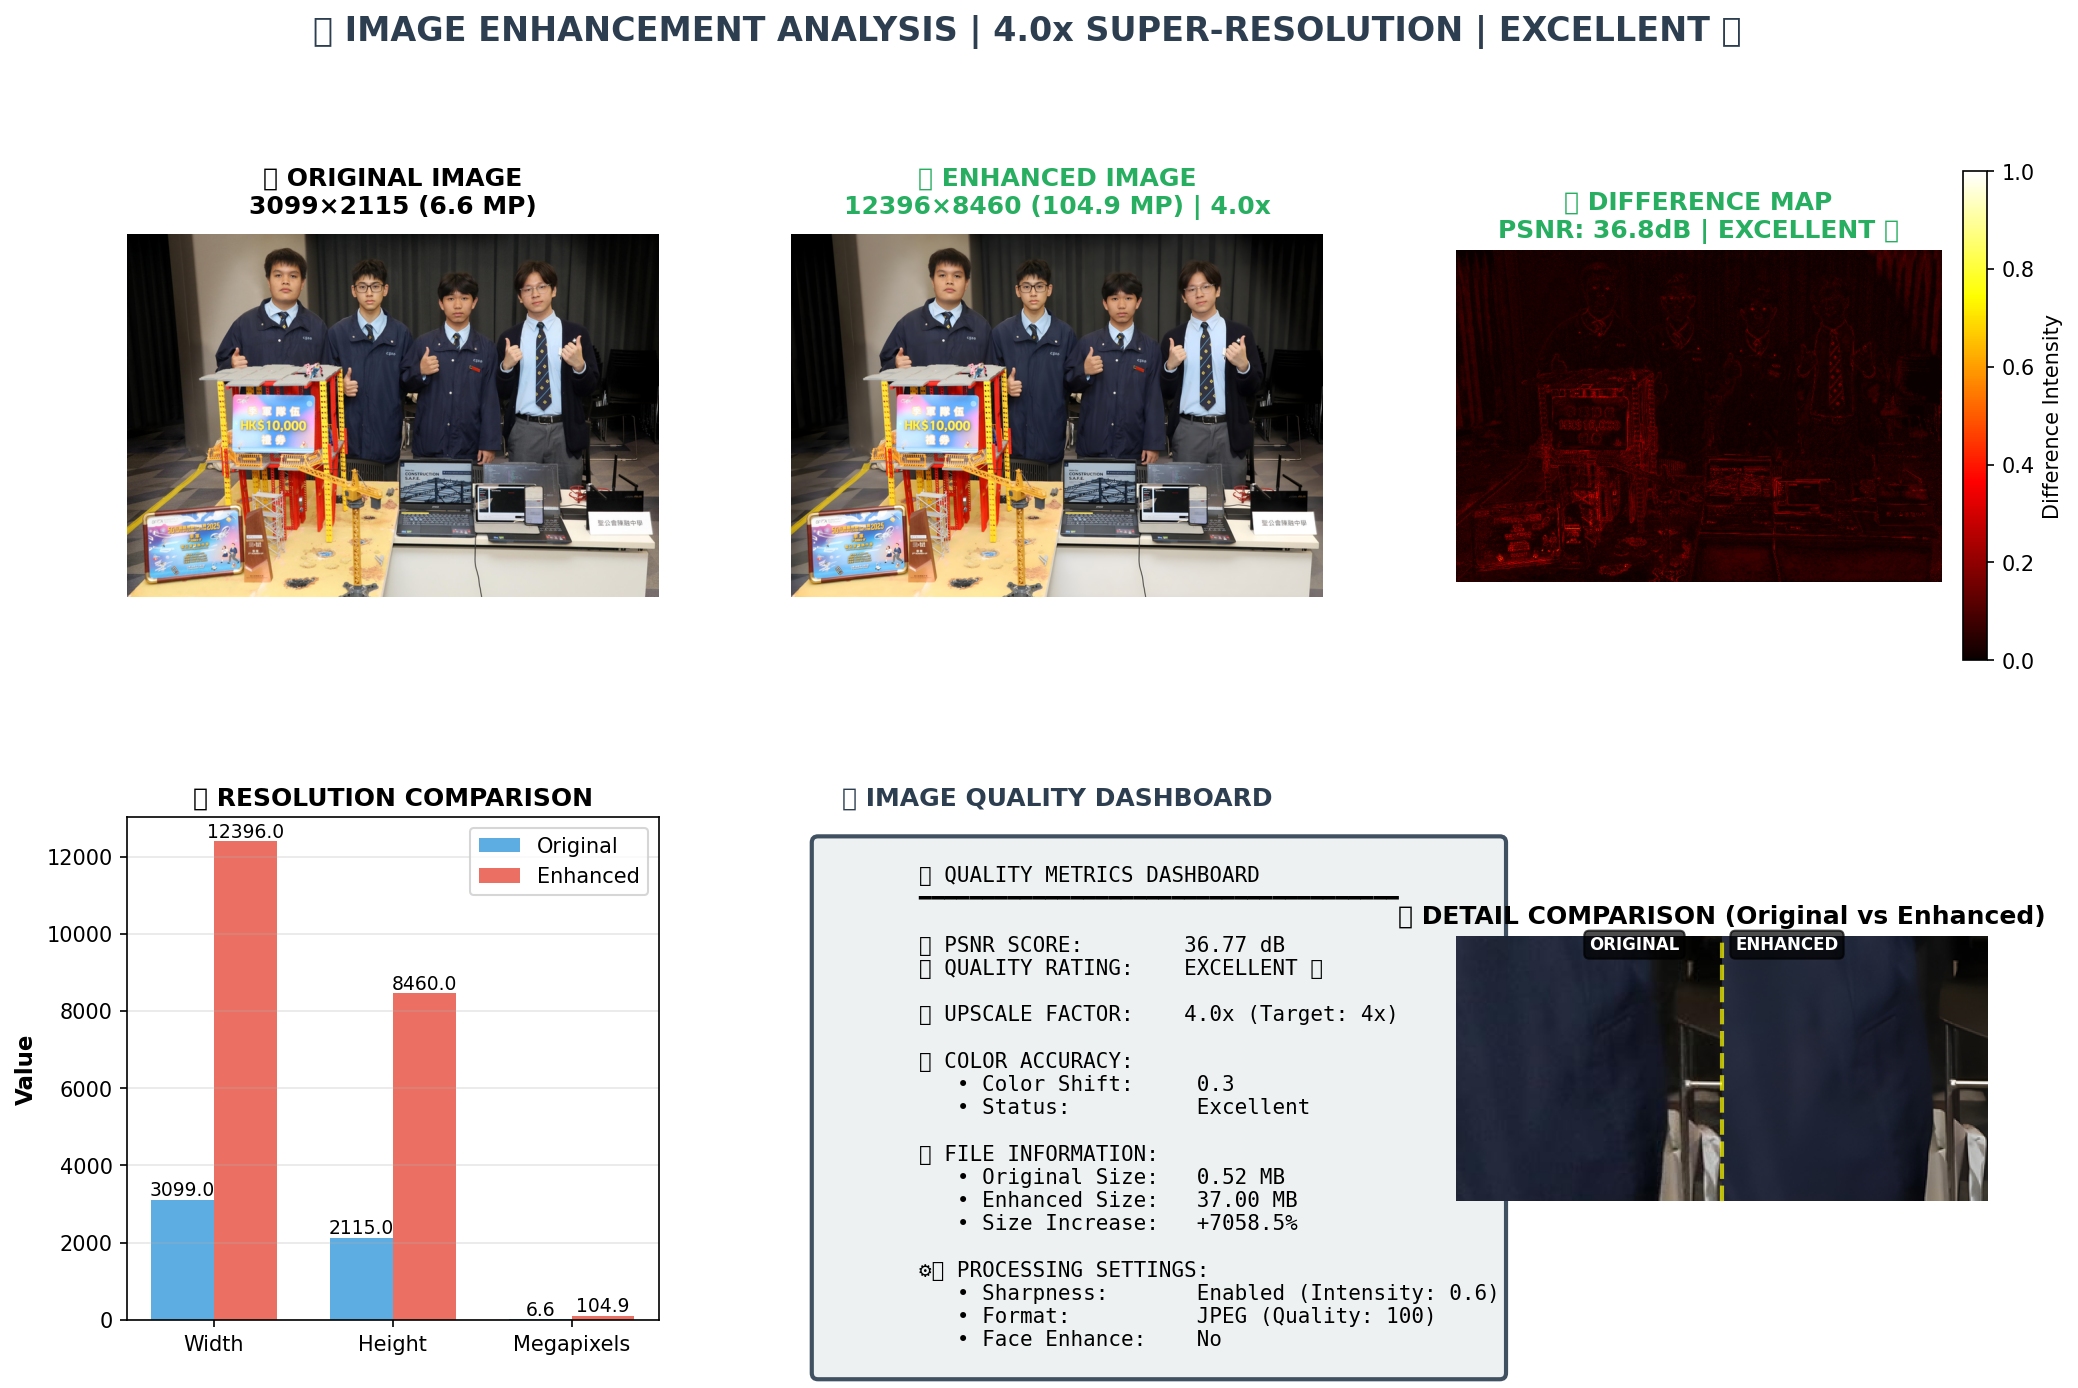


                             📊 ENHANCEMENT SUMMARY                              
📐 RESOLUTION:      3099×2115 → 12396×8460
📈 UPSCALE FACTOR:  4.0x (Target: 4x)
🎯 PSNR SCORE:      36.77 dB 🎉 Excellent
🎨 COLOR SHIFT:     0.3 (Excellent < 2)
💾 FILE SIZE:       0.52 MB → 37.00 MB
📊 QUALITY RATING:  EXCELLENT 🎉


📦 Created ZIP archive: 36.94 MB
📥 Downloading ZIP archive...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 Pipeline completed successfully!
📁 Output folder: /content/output

                           ✨ FINAL PROCESSING SUMMARY                           
📸 Images processed: 1
📐 Target upscale: 4x
⚙️ Sharpness: Enabled (intensity: 0.6)
🎨 Output format: JPEG (quality: 100)
👤 Face enhancement: No
🎮 GPU acceleration: Yes

✨ Enhancement pipeline completed successfully! ✨


In [ ]:
#@title 2. 🚀 Quick-Enhance Panel (Gigapixel, Metadata Sync, Sharpness & Fast Mode)
upscale_factor = 4 #@param {type:"slider", min:2, max:32, step:2}
tile_size = 512 #@param {type:"slider", min:0, max:2048, step:128}
enhance_faces = False #@param {type:"boolean"}
opencv_method = "Lanczos4" #@param ["Lanczos4", "Bicubic", "Linear"]
apply_sharpness = True #@param {type:"boolean"}
sharpness_intensity = 0.6 #@param {type:"slider", min:0.1, max:2.0, step:0.1}
max_edge_resolution = "No Limit" #@param ["4K", "8K", "12K", "16K", "No Limit"]
output_folder = "/content/output" #@param {type:"string"}
show_plots = True #@param {type:"boolean"}
plot_dpi = 150 #@param {type:"slider", min:72, max:150, step:1}
save_plots = True #@param {type:"boolean"}
output_format = "JPEG" #@param ["JPEG", "PNG", "WEBP"]
output_quality = 100 #@param {type:"slider", min:70, max:100, step:1}

import sys
import subprocess
import warnings
warnings.filterwarnings('ignore')

# Install only essential packages
required_packages = ['pillow-heif', 'piexif', 'opencv-python']
for pkg in required_packages:
    pkg_name = pkg.replace('-', '_')
    if pkg_name not in sys.modules:
        print(f"📦 Installing {pkg}...")
        try:
            subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"],
                          check=True, capture_output=True)
        except subprocess.CalledProcessError as e:
            print(f"⚠️ Failed to install {pkg}, trying alternative method...")
            subprocess.run([sys.executable, "-m", "pip", "install", pkg, "--no-deps", "-q"])

import os
import glob
import shutil
import torch
import gc
import cv2
import numpy as np
from google.colab import files
from PIL import Image, ImageOps, ImageEnhance
import pillow_heif
import piexif
from pathlib import Path
from datetime import datetime

# Lightweight plotting imports (only if needed)
if show_plots:
    try:
        import matplotlib.pyplot as plt
        from matplotlib.gridspec import GridSpec
        import matplotlib.patches as patches
        LIGHTWEIGHT_PLOTS = True
        print("📊 Plotting mode enabled (optimized for speed)")
    except ImportError:
        print("⚠️ Matplotlib not available, installing...")
        subprocess.run([sys.executable, "-m", "pip", "install", "matplotlib", "-q"])
        import matplotlib.pyplot as plt
        from matplotlib.gridspec import GridSpec
        import matplotlib.patches as patches
        LIGHTWEIGHT_PLOTS = True
else:
    LIGHTWEIGHT_PLOTS = False
    print("⚡ Plotting disabled - maximum performance mode")

# Optimize PyTorch settings
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# Register HEIF support
pillow_heif.register_heif_opener()
Image.MAX_IMAGE_PIXELS = None

# ============================================================================
# ENHANCED PLOTTING FUNCTIONS WITH ACCURATE TRACKING
# ============================================================================

def calculate_quick_metrics(original, enhanced):
    """Ultra-fast metrics calculation"""
    # Ensure same size for metric calculation
    if original.shape != enhanced.shape:
        # Resize original to match enhanced for metrics
        h, w = enhanced.shape[:2]
        original_resized = cv2.resize(original, (w, h), interpolation=cv2.INTER_LANCZOS4)
        orig_float = original_resized.astype(np.float32)
    else:
        orig_float = original.astype(np.float32)

    enh_float = enhanced.astype(np.float32)

    # Quick PSNR
    mse = np.mean((orig_float - enh_float) ** 2)
    psnr = 20 * np.log10(255.0 / np.sqrt(mse)) if mse > 0 else float('inf')

    # Quick color difference
    mean_diff = np.abs(np.mean(original, axis=(0,1)) - np.mean(enhanced, axis=(0,1))).mean()

    return {
        'psnr': psnr,
        'mse': mse,
        'mean_diff': mean_diff,
        'time': datetime.now().strftime('%H:%M:%S')
    }

def plot_accurate_comparison(original_path, enhanced_path, dpi=96, upscale_factor_display=4):
    """Accurate comparison plot with true dimensions"""
    try:
        # Load full resolution images
        img_orig = Image.open(original_path).convert('RGB')
        img_enh = Image.open(enhanced_path).convert('RGB')

        # Get TRUE dimensions
        orig_w, orig_h = img_orig.size
        enh_w, enh_h = img_enh.size
        actual_upscale = enh_w / orig_w if orig_w > 0 else 1

        # Create display versions (scaled down for visualization only)
        max_display_size = 800
        display_orig = img_orig.copy()
        display_enh = img_enh.copy()

        if display_orig.width > max_display_size or display_orig.height > max_display_size:
            display_orig.thumbnail((max_display_size, max_display_size), Image.Resampling.LANCZOS)
        if display_enh.width > max_display_size or display_enh.height > max_display_size:
            display_enh.thumbnail((max_display_size, max_display_size), Image.Resampling.LANCZOS)

        arr_orig = np.array(display_orig)
        arr_enh = np.array(display_enh)

        # Calculate metrics on properly sized samples
        sample_size = (800, 600)
        metric_orig = np.array(img_orig.resize(sample_size, Image.Resampling.LANCZOS))
        metric_enh = np.array(img_enh.resize(sample_size, Image.Resampling.LANCZOS))
        metrics = calculate_quick_metrics(metric_orig, metric_enh)

        # Create figure with 4 panels for better feedback
        fig = plt.figure(figsize=(16, 10), dpi=dpi, facecolor='white')
        gs = GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.25)

        # Panel 1: Original Image
        ax1 = fig.add_subplot(gs[0, 0])
        ax1.imshow(arr_orig)
        ax1.set_title(f'📸 ORIGINAL IMAGE\n{orig_w}×{orig_h} ({orig_w*orig_h/1e6:.1f} MP)',
                     fontsize=12, fontweight='bold', pad=10)
        ax1.axis('off')

        # Panel 2: Enhanced Image
        ax2 = fig.add_subplot(gs[0, 1])
        ax2.imshow(arr_enh)
        ax2.set_title(f'✨ ENHANCED IMAGE\n{enh_w}×{enh_h} ({enh_w*enh_h/1e6:.1f} MP) | {actual_upscale:.1f}x',
                     fontsize=12, fontweight='bold', color='#27ae60', pad=10)
        ax2.axis('off')

        # Panel 3: Difference Heatmap
        diff = np.abs(arr_orig.astype(np.float32) - arr_enh.astype(np.float32))
        diff_norm = (diff - diff.min()) / (diff.max() - diff.min() + 1e-8)
        diff_gray = diff_norm.mean(axis=2)

        ax3 = fig.add_subplot(gs[0, 2])
        im = ax3.imshow(diff_gray, cmap='hot', vmin=0, vmax=1)

        # Quality rating
        if metrics['psnr'] >= 35:
            rating = "EXCELLENT 🎉"
            rating_color = '#27ae60'
        elif metrics['psnr'] >= 30:
            rating = "GOOD 👍"
            rating_color = '#f39c12'
        elif metrics['psnr'] >= 25:
            rating = "FAIR ⚠️"
            rating_color = '#e67e22'
        else:
            rating = "POOR ❌"
            rating_color = '#e74c3c'

        ax3.set_title(f'🔥 DIFFERENCE MAP\nPSNR: {metrics["psnr"]:.1f}dB | {rating}',
                     fontsize=12, fontweight='bold', color=rating_color)
        ax3.axis('off')
        cbar = plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
        cbar.set_label('Difference Intensity', fontsize=10)

        # Panel 4: Resolution Comparison Bar Chart
        ax4 = fig.add_subplot(gs[1, 0])
        categories = ['Width', 'Height', 'Megapixels']
        orig_values = [orig_w, orig_h, orig_w*orig_h/1e6]
        enh_values = [enh_w, enh_h, enh_w*enh_h/1e6]

        x = np.arange(len(categories))
        width = 0.35

        bars1 = ax4.bar(x - width/2, orig_values, width, label='Original', color='#3498db', alpha=0.8)
        bars2 = ax4.bar(x + width/2, enh_values, width, label='Enhanced', color='#e74c3c', alpha=0.8)

        ax4.set_ylabel('Value', fontsize=11, fontweight='bold')
        ax4.set_title('📊 RESOLUTION COMPARISON', fontsize=12, fontweight='bold')
        ax4.set_xticks(x)
        ax4.set_xticklabels(categories)
        ax4.legend()
        ax4.grid(True, alpha=0.3, axis='y')

        # Add value labels on bars
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                ax4.text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.1f}', ha='center', va='bottom', fontsize=9)

        # Panel 5: Quality Metrics Dashboard
        ax5 = fig.add_subplot(gs[1, 1])
        ax5.axis('off')

        # Create metrics text box
        metrics_text = f"""
        🎯 QUALITY METRICS DASHBOARD
        ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

        📈 PSNR SCORE:        {metrics['psnr']:.2f} dB
        📊 QUALITY RATING:    {rating}

        📐 UPSCALE FACTOR:    {actual_upscale:.1f}x (Target: {upscale_factor_display}x)

        🎨 COLOR ACCURACY:
           • Color Shift:     {metrics['mean_diff']:.1f}
           • Status:          {'Excellent' if metrics['mean_diff'] < 2 else 'Good' if metrics['mean_diff'] < 5 else 'Noticeable'}

        📁 FILE INFORMATION:
           • Original Size:   {os.path.getsize(original_path)/1024/1024:.2f} MB
           • Enhanced Size:   {os.path.getsize(enhanced_path)/1024/1024:.2f} MB
           • Size Increase:   +{((os.path.getsize(enhanced_path) - os.path.getsize(original_path))/os.path.getsize(original_path)*100):.1f}%

        ⚙️ PROCESSING SETTINGS:
           • Sharpness:       {'Enabled' if apply_sharpness else 'Disabled'} (Intensity: {sharpness_intensity})
           • Format:          {output_format} (Quality: {output_quality})
           • Face Enhance:    {'Yes' if enhance_faces else 'No'}
        """

        ax5.text(0.05, 0.95, metrics_text, transform=ax5.transAxes,
                fontsize=10, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='#ecf0f1', alpha=0.9, edgecolor='#2c3e50', linewidth=2))
        ax5.set_title('📊 IMAGE QUALITY DASHBOARD', fontsize=12, fontweight='bold', color='#2c3e50')

        # Panel 6: Detail Zoom Comparison
        ax6 = fig.add_subplot(gs[1, 2])

        # Extract center region for detail comparison
        zoom_size = min(orig_h, orig_w, 400) // 4
        center_y = orig_h // 2
        center_x = orig_w // 2

        # Get zoom region from original
        img_orig_array = np.array(img_orig)
        if len(img_orig_array.shape) == 2:
            img_orig_array = np.stack([img_orig_array] * 3, axis=-1)

        zoom_orig = img_orig_array[center_y-zoom_size:center_y+zoom_size,
                                  center_x-zoom_size:center_x+zoom_size]

        # Get zoom region from enhanced (scale coordinates)
        enh_center_y = enh_h // 2
        enh_center_x = enh_w // 2
        zoom_enh_size = zoom_size * int(actual_upscale)

        img_enh_array = np.array(img_enh)
        if len(img_enh_array.shape) == 2:
            img_enh_array = np.stack([img_enh_array] * 3, axis=-1)

        zoom_enh = img_enh_array[enh_center_y-zoom_enh_size:enh_center_y+zoom_enh_size,
                                enh_center_x-zoom_enh_size:enh_center_x+zoom_enh_size]

        # Resize zoom_enh to match zoom_orig for side-by-side
        zoom_enh_resized = np.array(Image.fromarray(zoom_enh).resize((zoom_size*2, zoom_size*2), Image.Resampling.LANCZOS))

        # Create side-by-side zoom comparison
        zoom_comparison = np.hstack([zoom_orig, zoom_enh_resized])
        ax6.imshow(zoom_comparison)
        ax6.set_title('🔍 DETAIL COMPARISON (Original vs Enhanced)', fontsize=12, fontweight='bold')
        ax6.axis('off')

        # Add dividing line
        ax6.axvline(x=zoom_size*2, color='yellow', linewidth=2, linestyle='--', alpha=0.7)
        ax6.text(zoom_size, 10, 'ORIGINAL', fontsize=8, color='white', fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))
        ax6.text(zoom_size*2 + 10, 10, 'ENHANCED', fontsize=8, color='white', fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

        # Main title
        plt.suptitle(f'🎯 IMAGE ENHANCEMENT ANALYSIS | {actual_upscale:.1f}x SUPER-RESOLUTION | {rating}',
                    fontsize=16, fontweight='bold', y=0.98, color='#2c3e50')

        plt.tight_layout()
        plt.show()

        # Print detailed summary to console
        print("\n" + "="*80)
        print("📊 ENHANCEMENT SUMMARY".center(80))
        print("="*80)
        print(f"📐 RESOLUTION:      {orig_w}×{orig_h} → {enh_w}×{enh_h}")
        print(f"📈 UPSCALE FACTOR:  {actual_upscale:.1f}x (Target: {upscale_factor_display}x)")
        print(f"🎯 PSNR SCORE:      {metrics['psnr']:.2f} dB", end=" ")
        if metrics['psnr'] >= 35:
            print("🎉 Excellent")
        elif metrics['psnr'] >= 30:
            print("👍 Good")
        else:
            print("📉 Needs improvement")
        print(f"🎨 COLOR SHIFT:     {metrics['mean_diff']:.1f} (Excellent < 2)")
        print(f"💾 FILE SIZE:       {os.path.getsize(original_path)/1024/1024:.2f} MB → {os.path.getsize(enhanced_path)/1024/1024:.2f} MB")
        print(f"📊 QUALITY RATING:  {rating}")
        print("="*80 + "\n")

        return True, metrics

    except Exception as e:
        print(f"⚠️ Plot generation failed: {str(e)}")
        import traceback
        traceback.print_exc()
        return False, None

def check_gpu_memory():
    """Check and report GPU memory status"""
    if torch.cuda.is_available():
        free_memory = torch.cuda.mem_get_info()[0] / 1e9
        total_memory = torch.cuda.mem_get_info()[1] / 1e9
        used_memory = total_memory - free_memory
        print(f"🎮 GPU Memory: {used_memory:.1f}GB used / {free_memory:.1f}GB free / {total_memory:.1f}GB total")
        if free_memory < 2.0:
            print("⚠️ WARNING: Low GPU memory! Consider reducing tile_size")
            return False
        return True
    else:
        print("⚠️ No GPU detected, using CPU (will be slower)")
        return False

# Ensure we're in the right directory
if not os.path.exists('/content/Real-ESRGAN'):
    print("📦 Cloning Real-ESRGAN repository...")
    subprocess.run(["git", "clone", "https://github.com/xinntao/Real-ESRGAN.git", "/content/Real-ESRGAN"])
    subprocess.run([sys.executable, "-m", "pip", "install", "-r", "/content/Real-ESRGAN/requirements.txt", "-q"])

os.chdir('/content/Real-ESRGAN')

# Clear CUDA cache
print(f"🔄 Clearing PyTorch CUDA cache...")
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

# Check GPU memory
check_gpu_memory()

# Clean and create directories
for f in ['inputs', 'results', output_folder]:
    if os.path.exists(f):
        try:
            shutil.rmtree(f)
        except Exception as e:
            print(f"⚠️ Could not remove {f}: {e}")
    os.makedirs(f, exist_ok=True)

print("\n📁 Select your image(s):")
uploaded = files.upload()

if not uploaded:
    print("⚠️ Upload cancelled. Exiting...")
else:
    print("\n📊 --- STAGE 1: DISK-STREAM INGESTION & METADATA CACHE ---")

    metadata_cache = {}
    processed_files = []
    original_file_map = {}  # Map AI output to original uploaded file

    for idx, (name, file_bytes) in enumerate(uploaded.items(), 1):
        try:
            clean_name = "".join(c for c in name if c.isalnum() or c in '._- ')
            clean_name = clean_name.replace(" ", "_")
            target_path = os.path.join('inputs', clean_name)

            with open(target_path, 'wb') as f_out:
                f_out.write(file_bytes)

            ext = os.path.splitext(clean_name)[1].lower()
            if ext in ['.heic', '.heif']:
                jpg_path = os.path.splitext(target_path)[0] + '.jpg'
                with Image.open(target_path) as img_obj:
                    if "exif" in img_obj.info:
                        metadata_cache[os.path.basename(jpg_path)] = img_obj.info["exif"]
                    img_obj.convert('RGB').save(jpg_path, 'JPEG', quality=95, optimize=True)
                os.remove(target_path)
                target_path = jpg_path
                processed_files.append(target_path)
                original_file_map[os.path.basename(jpg_path)] = target_path
            else:
                with Image.open(target_path) as img_obj:
                    if "exif" in img_obj.info:
                        metadata_cache[os.path.basename(target_path)] = img_obj.info["exif"]
                processed_files.append(target_path)
                original_file_map[os.path.basename(target_path)] = target_path

            with Image.open(target_path) as img:
                mp = (img.width * img.height) / 1000000
                print(f"   ✅ Loaded: {os.path.basename(target_path)} | {img.width}×{img.height} ({mp:.2f} MP)")

        except Exception as e:
            print(f"   ❌ Failed to process {name}: {str(e)}")
            continue

    del uploaded
    gc.collect()

    if not processed_files:
        print("❌ No valid images were uploaded or processed.")
    else:
        # Prepare Real-ESRGAN command
        face_flag = "--face_enhance" if enhance_faces else ""
        ai_scale = min(4, upscale_factor) if upscale_factor > 4 else upscale_factor

        print("\n🤖 --- STAGE 2: REAL-ESRGAN AI ENGINE ---")
        print(f"⚙️ AI upscale factor: {ai_scale}x (base model is 4x)")
        if upscale_factor > 4:
            print(f"📐 Will apply additional {upscale_factor/4:.1f}x scaling in post-processing")

        run_cmd = [
            "python", "inference_realesrgan.py",
            "-n", "RealESRGAN_x4plus",
            "-i", "inputs",
            "-o", "results",
            "--outscale", str(ai_scale),
            "--tile", str(tile_size if tile_size > 0 else 512),
            "--tile_pad", "10"
        ]
        if face_flag:
            run_cmd.append(face_flag)

        print(f"🖥️ Running Real-ESRGAN...")

        try:
            process = subprocess.run(run_cmd, capture_output=True, text=True, timeout=3600)

            if process.returncode != 0:
                print(f"\n⚠️ Primary execution had issues. Trying fallback mode...")
                if process.stderr:
                    print(f"Error: {process.stderr[:500]}")
                fallback_cmd = run_cmd.copy()
                for i, arg in enumerate(fallback_cmd):
                    if arg == "--tile":
                        fallback_cmd[i+1] = "256"
                        break

                fallback_process = subprocess.run(fallback_cmd, capture_output=True, text=True, timeout=3600)
                if fallback_process.returncode != 0:
                    print(f"❌ Fallback also failed!")
                    if fallback_process.stderr:
                        print(f"Error: {fallback_process.stderr[:500]}")
                    raise Exception("Real-ESRGAN processing failed")
                else:
                    print("✅ Fallback mode succeeded!")

        except subprocess.TimeoutExpired:
            print("❌ Processing timed out after 1 hour")
            raise
        except Exception as e:
            print(f"❌ Failed to run Real-ESRGAN: {str(e)}")
            raise

        print(f"\n📐 --- STAGE 3: POST-PROCESSING & METADATA INJECTION ---")

        results_files = glob.glob('results/*')

        if not results_files:
            print("❌ No output files generated by Real-ESRGAN")
        else:
            pil_methods = {
                "Lanczos4": Image.Resampling.LANCZOS,
                "Bicubic": Image.Resampling.BICUBIC,
                "Bilinear": Image.Resampling.BILINEAR
            }

            res_mapping = {"4K": 3840, "8K": 7680, "12K": 11520, "16K": 15360}
            max_edge = res_mapping.get(max_edge_resolution, None) if max_edge_resolution != "No Limit" else None

            final_images = []
            comparison_pairs = []  # Store (original_path, enhanced_path) for plotting

            for idx, path in enumerate(results_files):
                try:
                    print(f"\n   ⏳ [{idx+1}/{len(results_files)}] Processing: {os.path.basename(path)}")

                    img = Image.open(path)
                    img_final = img
                    out_filename = os.path.basename(path)

                    # Get original filename
                    base_name = os.path.splitext(out_filename)[0]
                    orig_key = base_name.replace('_out', '')

                    # Find matching original file
                    original_path = None
                    for key, orig_path in original_file_map.items():
                        if os.path.splitext(key)[0] == orig_key or orig_key in key:
                            original_path = orig_path
                            break

                    if not original_path and original_file_map:
                        original_path = list(original_file_map.values())[0]

                    # Load original to get dimensions
                    if original_path and os.path.exists(original_path):
                        with Image.open(original_path) as orig_img:
                            orig_w, orig_h = orig_img.size
                            print(f"   📐 Original: {orig_w}×{orig_h}")

                    # Apply additional scaling
                    if upscale_factor > 4:
                        pil_scale = upscale_factor / 4.0
                        new_width = int(img.width * pil_scale)
                        new_height = int(img.height * pil_scale)
                        print(f"   📐 Additional upscaling: 4x → {upscale_factor}x")
                        img_final = img.resize((new_width, new_height), resample=pil_methods[opencv_method])
                        out_filename = f"{base_name.replace('_out', '')}_{upscale_factor}x.{output_format.lower()}"
                    elif upscale_factor < 4:
                        down_scale = upscale_factor / 4.0
                        new_width = int(img.width * down_scale)
                        new_height = int(img.height * down_scale)
                        print(f"   📐 Downscaling: 4x → {upscale_factor}x")
                        img_final = img.resize((new_width, new_height), resample=pil_methods[opencv_method])
                        out_filename = f"{base_name.replace('_out', '')}_{upscale_factor}x.{output_format.lower()}"
                    else:
                        out_filename = f"{base_name.replace('_out', '')}.{output_format.lower()}"
                        print(f"   📐 Keeping 4x upscale from AI model")

                    # Apply resolution limit
                    if max_edge:
                        w, h = img_final.size
                        if max(w, h) > max_edge:
                            if w > h:
                                new_w = max_edge
                                new_h = int(h * (max_edge / w))
                            else:
                                new_h = max_edge
                                new_w = int(w * (max_edge / h))
                            img_final = img_final.resize((new_w, new_h), Image.Resampling.LANCZOS)
                            print(f"   📏 Limited to {max_edge_resolution}: {new_w}×{new_h}")

                    # Apply sharpness
                    if apply_sharpness and sharpness_intensity > 0:
                        try:
                            print(f"   ✨ Applying sharpness (intensity: {sharpness_intensity})")
                            cv_img = cv2.cvtColor(np.array(img_final), cv2.COLOR_RGB2BGR)
                            gaussian_blur = cv2.GaussianBlur(cv_img, (0, 0), sigmaX=1.0)
                            cv_sharpened = cv2.addWeighted(cv_img, 1.0 + sharpness_intensity,
                                                          gaussian_blur, -sharpness_intensity, 0)
                            cv_sharpened = np.clip(cv_sharpened, 0, 255).astype(np.uint8)
                            img_final = Image.fromarray(cv2.cvtColor(cv_sharpened, cv2.COLOR_BGR2RGB))
                        except Exception as e:
                            print(f"   ⚠️ Sharpening failed: {e}")

                    # Restore metadata
                    exif_data = b""
                    if original_path:
                        orig_filename = os.path.basename(original_path)
                        if orig_filename in metadata_cache:
                            exif_data = metadata_cache[orig_filename]

                    # Save final image
                    final_dest = os.path.join(output_folder, out_filename)

                    save_kwargs = {'optimize': True}
                    if output_format == "JPEG":
                        save_kwargs['quality'] = output_quality
                        if exif_data and len(exif_data) > 0:
                            save_kwargs['exif'] = exif_data
                    elif output_format == "PNG":
                        save_kwargs['compress_level'] = 6
                        if exif_data and len(exif_data) > 0:
                            save_kwargs['exif'] = exif_data
                    elif output_format == "WEBP":
                        save_kwargs['quality'] = output_quality
                        save_kwargs['method'] = 4

                    img_final.save(final_dest, **save_kwargs)
                    final_images.append(final_dest)

                    # Store for comparison
                    if original_path and os.path.exists(original_path):
                        comparison_pairs.append((original_path, final_dest))

                    # Display file info
                    final_size_mb = os.path.getsize(final_dest) / (1024 * 1024)
                    print(f"   ✅ Saved: {out_filename}")
                    print(f"      📏 Size: {img_final.width}×{img_final.height} ({img_final.width*img_final.height/1e6:.1f} MP)")
                    print(f"      💾 File: {final_size_mb:.2f} MB")

                    del img, img_final

                except Exception as e:
                    print(f"   ❌ Failed to process {path}: {str(e)}")
                    import traceback
                    traceback.print_exc()
                    continue

            print(f"\n📦 --- STAGE 4: VISUAL FEEDBACK & DOWNLOAD ---")

            if final_images:
                print(f"✅ Successfully processed {len(final_images)} image(s)")

                # Generate accurate comparison plots
                if LIGHTWEIGHT_PLOTS and show_plots and comparison_pairs:
                    print("\n🎨 Generating enhanced visual feedback...")
                    for orig_path, enh_path in comparison_pairs:
                        print(f"\n📸 Analyzing: {os.path.basename(orig_path)}")
                        plot_accurate_comparison(orig_path, enh_path, dpi=plot_dpi, upscale_factor_display=upscale_factor)

                # Create ZIP archive
                zip_name = f'/content/Enhanced_{upscale_factor}x_{len(final_images)}images_{datetime.now().strftime("%Y%m%d_%H%M%S")}'
                try:
                    shutil.make_archive(zip_name, 'zip', output_folder)
                    zip_path = f'{zip_name}.zip'
                    if os.path.exists(zip_path):
                        zip_size = os.path.getsize(zip_path) / (1024 * 1024)
                        print(f"\n📦 Created ZIP archive: {zip_size:.2f} MB")
                        print(f"📥 Downloading ZIP archive...")
                        files.download(zip_path)
                        print(f"\n🎉 Pipeline completed successfully!")
                        print(f"📁 Output folder: {output_folder}")
                except Exception as e:
                    print(f"❌ Error creating ZIP: {str(e)}")

                # Final summary
                print("\n" + "="*80)
                print("✨ FINAL PROCESSING SUMMARY".center(80))
                print("="*80)
                print(f"📸 Images processed: {len(final_images)}")
                print(f"📐 Target upscale: {upscale_factor}x")
                print(f"⚙️ Sharpness: {'Enabled' if apply_sharpness else 'Disabled'} (intensity: {sharpness_intensity})")
                print(f"🎨 Output format: {output_format} (quality: {output_quality})")
                print(f"👤 Face enhancement: {'Yes' if enhance_faces else 'No'}")
                print(f"🎮 GPU acceleration: {'Yes' if torch.cuda.is_available() else 'No'}")
                print("="*80)

            else:
                print("❌ No images were successfully processed")

            # Cleanup
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            print("\n✨ Enhancement pipeline completed successfully! ✨")